# SALTwatch: The State-and-Local-Tax (SALT) Deduction Cap Dilemma

An end-to-end **pandas + NumPy + visualization** project on a genuinely
current tax dilemma: the temporary, income-phased SALT deduction cap
created by the 2025 One Big Beautiful Bill Act (OBBBA) — and the "cliff"
it's set to fall off in 2030.

### The dilemma, in one sentence

Raising the SALT cap gives real, meaningful relief to upper-middle and
high-income households in high-tax states — but it's temporary, it phases
out sharply for high earners in a way that can spike their *effective*
marginal tax rate (the "SALT torpedo"), it mostly bypasses low- and
middle-income households who don't pay enough state/local tax to benefit,
and it's scheduled to disappear entirely in 2030 — creating a genuinely
hard planning problem with no clean answer.

### Grounding this in the real law

- The 2017 Tax Cuts and Jobs Act (TCJA) capped the SALT deduction at
  **$10,000** ($5,000 for married filing separately) for tax years 2018-2025.
- The **One Big Beautiful Bill Act (OBBBA)**, signed July 4, 2025, raised
  the cap to **$40,000** ($20,000 MFS) for **2025**, rising **1% per year
  through 2029** (e.g. **$40,400 in 2026**), and applies **only to
  taxpayers who itemize** (Bipartisan Policy Center; TaxSlayer Pro; H&R
  Block; TurboTax; 2025-2026).
- The higher cap **phases out** for taxpayers with modified adjusted gross
  income (MAGI) above **$500,000** ($250,000 MFS) — reduced by **30% of
  the excess MAGI** over that threshold, down to a statutory floor of
  **$10,000** ($5,000 MFS), which is fully reached at **MAGI $600,000**
  ($300,000 MFS). The threshold itself also rises 1%/year through 2029
  (Holthouse Carlin & Van Trigt; Kahn Litwin; STW; 2025-2026).
- This phase-out creates what practitioners call the **"SALT torpedo"**:
  because *every additional dollar* of MAGI between $500K and $600K both
  raises taxable income *and* shrinks the SALT deduction at the same time,
  a taxpayer's *effective* marginal tax rate in that band can spike well
  above their statutory bracket rate (CNBC; Kahn Litwin, 2025-2026).
- The **higher cap reverts to $10,000 with no income limit starting in
  2030** — the same cliff structure that made the original TCJA
  provisions a recurring source of last-minute uncertainty (Bipartisan
  Policy Center; STW; 2025-2026).
- Since the SALT deduction only matters if you **itemize**, and the
  TCJA-era standard deduction (made **permanent** by OBBBA — $15,750
  single / $31,500 married filing jointly for 2025, rising to $16,100 /
  $32,200 for 2026) is now so much higher than pre-2018 levels, roughly
  **90% of taxpayers** take the standard deduction rather than itemizing
  at all (Bipartisan Policy Center; CountryTaxCalc; IRS Rev. Proc.
  2025-32; 2025-2026).

> **What's real vs. synthetic in this notebook:** the SALT cap schedule,
> phase-out formula, standard deduction amounts, and the "~90% take the
> standard deduction" statistic are all **real, cited figures** — and the
> SALT-cap calculator built in Section 3 implements the **actual statutory
> formula**, validated against a real worked example from the cited
> sources. The **taxpayer microdata (incomes, states, SALT paid, other
> itemized deductions) is synthetic**, calibrated to realistic patterns,
> since individual IRS return data isn't publicly available at the
> record level.

### What this notebook covers
1. Real reference data: the SALT cap schedule and standard deduction amounts
2. Building the SALT cap as an exact, vectorized NumPy function of the law
3. Synthetic taxpayer microdata, calibrated to realistic income/state/deduction patterns
4. The itemize-vs-standard decision (boolean masks, broadcasting across years)
5. The "SALT torpedo": visualizing the effective marginal rate spike
6. Who benefits: distribution by income and state (`groupby`, geographic view)
7. The 2030 cliff
8. A one-page dashboard
9. Wrap-up: what this data does and doesn't settle


In [1]:
# Core imports used throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

rng = np.random.default_rng(2025)

pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 110)
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3,
                      "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

print("pandas :", pd.__version__)
print("numpy  :", np.__version__)


pandas : 3.0.2
numpy  : 2.4.4


## 1. Real reference data


In [2]:
# ---------------------------------------------------------------
# REAL DATA: the SALT cap and phase-out threshold, computed for every year
# 2018-2031 DIRECTLY from the statutory formula (not fitted or estimated):
#   - 2018-2024: flat $10,000 cap ($5,000 MFS), no income phase-out (TCJA)
#   - 2025-2029: $40,000 cap ($20,000 MFS), rising 1%/year; phases out at
#     30% of MAGI over a $500,000 threshold (also rising 1%/year), floor $10,000
#   - 2030+: reverts to flat $10,000 cap, no phase-out (OBBBA sunset)
# Source: OBBBA (P.L. 119-21) as summarized by Holthouse Carlin & Van Trigt,
# Kahn Litwin, Bipartisan Policy Center, and STW (2025-2026)
# ---------------------------------------------------------------
schedule_years = np.arange(2018, 2032)

def salt_law_parameters(year):
    """Return (base_cap, phaseout_threshold) for MFJ/Single, for a given year,
    exactly per the statute. MFS taxpayers use exactly half of both figures."""
    if year < 2025 or year >= 2030:
        return 10_000, None          # flat cap, no phase-out ever applies
    n = year - 2025                   # 0 for 2025, 1 for 2026, ... 4 for 2029
    base_cap = 40_000 * (1.01 ** n)
    threshold = 500_000 * (1.01 ** n)
    return base_cap, threshold

salt_schedule = pd.DataFrame([
    {"year": y, "base_cap": salt_law_parameters(y)[0], "phaseout_threshold": salt_law_parameters(y)[1]}
    for y in schedule_years
])
salt_schedule


,year,base_cap,phaseout_threshold
0,2018,10000.0000,NaN
1,2019,10000.0000,NaN
2,2020,10000.0000,NaN
3,2021,10000.0000,NaN
4,2022,10000.0000,NaN
5,2023,10000.0000,NaN
6,2024,10000.0000,NaN
7,2025,40000.0000,500000.000
8,2026,40400.0000,505000.000
9,2027,40804.0000,510050.000


In [3]:
# ---------------------------------------------------------------
# REAL DATA: standard deduction amounts, key years (post-TCJA/OBBBA)
# Source: Katten Muchin Rosenman; PwC Tax Summaries; IRS Rev. Proc. 2025-32
# ---------------------------------------------------------------
real_standard_deduction = pd.DataFrame({
    "year": [2017, 2018, 2024, 2025, 2026],
    "single_mfs": [6_350, 12_000, 14_600, 15_750, 16_100],
    "mfj": [12_700, 24_000, 29_200, 31_500, 32_200],
    "note": ["pre-TCJA", "TCJA nearly doubles it", "pre-OBBBA (inflation-adjusted TCJA level)",
              "OBBBA permanently raises it further", "inflation-adjusted"],
})
real_standard_deduction


,year,single_mfs,mfj,note
0,2017,6350,12700,pre-TCJA
1,2018,12000,24000,TCJA nearly doubles it
2,2024,14600,29200,pre-OBBBA (inflation-adjusted TCJA level)
3,2025,15750,31500,OBBBA permanently raises it further
4,2026,16100,32200,inflation-adjusted


In [4]:
# ---------------------------------------------------------------
# VALIDATE the SALT cap function against a REAL worked example from the
# cited sources: a single filer who paid $37,000 in SALT with a 2025 MAGI
# of $520,000 should have their allowed deduction reduced to exactly $34,000.
# ---------------------------------------------------------------
def allowed_salt_deduction(magi, salt_paid, year, filing_status="single_or_mfj"):
    """Vectorized (NumPy-broadcast-friendly) implementation of the exact
    statutory SALT deduction cap, including the MAGI-based phase-out."""
    base_cap, threshold = salt_law_parameters(year)
    if filing_status == "mfs":
        base_cap = base_cap / 2
        if threshold is not None:
            threshold = threshold / 2
        floor = 5_000
    else:
        floor = 10_000

    if threshold is None:            # years with NO phase-out (pre-2025 or post-2029)
        cap = np.full_like(np.asarray(magi, dtype=float), base_cap)
    else:
        phase_down = np.clip(0.30 * (magi - threshold), 0, None)
        cap = np.clip(base_cap - phase_down, floor, base_cap)

    return np.minimum(salt_paid, cap)

# The real worked example
example_allowed = allowed_salt_deduction(magi=520_000, salt_paid=37_000, year=2025)
print(f"Worked-example check: single filer, MAGI $520,000, SALT paid $37,000, year 2025")
print(f"Computed allowed deduction: ${float(example_allowed):,.0f}   (real cited answer: $34,000)")
assert abs(float(example_allowed) - 34_000) < 1, "Validation against the real worked example failed!"
print("Validation PASSED -- our function reproduces the real published example exactly.")


Worked-example check: single filer, MAGI $520,000, SALT paid $37,000, year 2025
Computed allowed deduction: $34,000   (real cited answer: $34,000)
Validation PASSED -- our function reproduces the real published example exactly.


## 2. Synthetic Taxpayer Microdata

We generate a realistic population of itemizing-eligible households:
income (MAGI), state (with realistic state/local tax burden differences),
filing status, and the components of their itemized deductions.


In [5]:
n_taxpayers = 15_000

# Income: reuse the calibrated lognormal-with-Pareto-tail approach (as in
# the GiniLens inequality notebook) since SALT-relevant households skew
# toward the upper part of the income distribution
def simulate_incomes(sigma, pareto_top_pct, pareto_alpha, n, mu=11.2, seed=0):
    g = np.random.default_rng(seed)
    incomes = g.lognormal(mean=mu, sigma=sigma, size=n)
    n_top = int(n * pareto_top_pct / 100)
    if n_top > 0:
        top_idx = np.argsort(incomes)[-n_top:]
        floor = incomes[top_idx].min()
        incomes[top_idx] = (g.pareto(pareto_alpha, n_top) + 1) * floor
    return incomes

magi = simulate_incomes(sigma=0.75, pareto_top_pct=4, pareto_alpha=2.2, n=n_taxpayers, seed=11)
magi = np.clip(magi, 25_000, 8_000_000)

# Filing status
filing_status = rng.choice(["single_or_mfj", "mfs"], size=n_taxpayers, p=[0.96, 0.04])

# States: a mix of HIGH state/local tax burden states and NO/LOW state
# income tax states, each with a realistic effective SALT RATE (state
# income tax + property tax, as a % of income) -- this is what drives SALT
# paid, not just income level
state_profiles = {
    "California":     0.095, "New York":   0.11,  "New Jersey":  0.105,
    "Connecticut":    0.09,  "Illinois":   0.08,  "Massachusetts": 0.075,
    "Maryland":       0.085, "Oregon":     0.09,
    "Texas":          0.018, "Florida":    0.015, "Washington":  0.017,
    "Nevada":         0.014, "Tennessee":  0.016,
    "Ohio":           0.045, "Georgia":    0.05,  "Arizona":     0.04,
}
states = np.array(list(state_profiles.keys()))
state_weights = np.array([0.09, 0.08, 0.045, 0.02, 0.055, 0.035, 0.03, 0.02,
                            0.11, 0.10, 0.04, 0.025, 0.03, 0.06, 0.05, 0.04])
state_weights = state_weights / state_weights.sum()
state = rng.choice(states, size=n_taxpayers, p=state_weights)
effective_salt_rate = np.array([state_profiles[s] for s in state])

salt_paid = magi * effective_salt_rate * rng.uniform(0.85, 1.15, n_taxpayers)
salt_paid = np.clip(salt_paid, 500, 120_000)   # property+income tax rarely below a few hundred, capped for realism

# Other itemizable deductions: mortgage interest + charitable giving, both
# loosely scaling with income (higher earners give/borrow more in dollar terms)
mortgage_interest = np.clip(rng.normal(magi * 0.045, magi * 0.02), 0, 60_000)
charitable = np.clip(rng.normal(magi * 0.02, magi * 0.015), 0, 200_000)

taxpayers = pd.DataFrame({
    "taxpayer_id": np.arange(1, n_taxpayers + 1),
    "magi": magi.round(0), "filing_status": filing_status, "state": state,
    "salt_paid": salt_paid.round(0), "mortgage_interest": mortgage_interest.round(0),
    "charitable": charitable.round(0),
})
taxpayers.head()


,taxpayer_id,magi,filing_status,state,salt_paid,mortgage_interest,charitable
0,1,75030.0,mfs,Massachusetts,4891.0,3738.0,861.0
1,2,202767.0,single_or_mfj,Georgia,10709.0,14680.0,5640.0
2,3,183238.0,single_or_mfj,Tennessee,2823.0,10811.0,0.0
3,4,49875.0,single_or_mfj,Massachusetts,3947.0,1723.0,2584.0
4,5,58485.0,mfs,Florida,780.0,3813.0,1420.0


## 3. Broadcasting Across Years: Every Taxpayer, Every Year, At Once

Now the key NumPy move: instead of looping over years, we compute the
allowed SALT deduction for **all 15,000 taxpayers across all 14 years
(2018-2031) simultaneously**, using a 2D broadcast.


In [6]:
years_to_compute = np.arange(2018, 2032)
n_years = len(years_to_compute)

# Build the (n_years,) arrays of base_cap/threshold ONCE, then broadcast
# them against the (n_taxpayers,) MAGI array -- a (n_years, 1) x (1, n_taxpayers)
# style broadcast, producing an (n_years, n_taxpayers) allowed-deduction matrix
base_caps = np.array([salt_law_parameters(y)[0] for y in years_to_compute])
thresholds = np.array([salt_law_parameters(y)[1] if salt_law_parameters(y)[1] is not None else np.inf
                        for y in years_to_compute])

# For simplicity in this broadcast we treat all taxpayers as single_or_mfj
# (96% of our synthetic population); MFS is handled separately just below
phase_down = np.clip(0.30 * (magi[np.newaxis, :] - thresholds[:, np.newaxis]), 0, None)   # (n_years, n_taxpayers)
cap_matrix = np.clip(base_caps[:, np.newaxis] - phase_down, 10_000, base_caps[:, np.newaxis])
allowed_matrix = np.minimum(salt_paid[np.newaxis, :], cap_matrix)   # (n_years, n_taxpayers)

print(f"allowed_matrix shape: {allowed_matrix.shape}  (years x taxpayers)")
print(f"\nAverage allowed SALT deduction by year (first 15,000 taxpayers, single/MFJ formula):")
pd.Series(allowed_matrix.mean(axis=1).round(0), index=years_to_compute, name="avg_allowed_salt")


allowed_matrix shape: (14, 15000)  (years x taxpayers)

Average allowed SALT deduction by year (first 15,000 taxpayers, single/MFJ formula):


2018    4418.0
2019    4418.0
2020    4418.0
2021    4418.0
2022    4418.0
2023    4418.0
2024    4418.0
2025    5387.0
2026    5393.0
2027    5398.0
2028    5402.0
2029    5407.0
2030    4418.0
2031    4418.0
Name: avg_allowed_salt, dtype: float64

In [7]:
# The TOTAL benefit of the higher cap: how much MORE could the average
# taxpayer deduct in 2025 vs. if the old $10,000 TCJA cap had stayed in force?
old_cap_allowed = np.minimum(salt_paid, 10_000)   # what everyone could deduct under the ORIGINAL TCJA cap
new_cap_allowed_2025 = allowed_matrix[years_to_compute.tolist().index(2025)]

benefit_2025 = new_cap_allowed_2025 - old_cap_allowed
taxpayers["salt_benefit_2025"] = benefit_2025.round(0)

print(f"Average additional SALT deduction gained in 2025 vs. the old $10,000 cap: "
      f"${taxpayers['salt_benefit_2025'].mean():,.0f}")
print(f"Median: ${taxpayers['salt_benefit_2025'].median():,.0f}")
print(f"{(taxpayers['salt_benefit_2025'] > 0).mean():.1%} of taxpayers gain SOME benefit from the higher cap")


Average additional SALT deduction gained in 2025 vs. the old $10,000 cap: $970
Median: $0
14.4% of taxpayers gain SOME benefit from the higher cap


## 4. The Itemize-vs-Standard Decision — Boolean Masks

The SALT cap only matters if you itemize in the first place. We compute
each taxpayer's total itemized deductions and compare against the real
2025 standard deduction to see who the higher cap actually reaches.


In [8]:
std_ded_single_mfj = 15_750   # real 2025 figure

total_itemized_2025 = new_cap_allowed_2025 + mortgage_interest + charitable
taxpayers["total_itemized_2025"] = total_itemized_2025.round(0)
taxpayers["itemizes_2025"] = total_itemized_2025 > std_ded_single_mfj

itemize_rate = taxpayers["itemizes_2025"].mean()
print(f"Share of our synthetic taxpayers who itemize in 2025: {itemize_rate:.1%}")
print(f"(Real-world context: ~90% of ALL U.S. taxpayers take the standard deduction; "
      f"our synthetic sample skews toward higher earners, so a higher itemization rate here is expected)")


Share of our synthetic taxpayers who itemize in 2025: 22.6%
(Real-world context: ~90% of ALL U.S. taxpayers take the standard deduction; our synthetic sample skews toward higher earners, so a higher itemization rate here is expected)


In [9]:
# Boolean masking: taxpayers who are ONLY itemizing BECAUSE of the higher
# cap -- i.e. they'd have taken the standard deduction under the old $10,000 cap
old_cap_total_itemized = old_cap_allowed + mortgage_interest + charitable
would_have_itemized_old_cap = old_cap_total_itemized > std_ded_single_mfj

newly_itemizing = taxpayers["itemizes_2025"] & ~would_have_itemized_old_cap
print(f"{newly_itemizing.sum():,} taxpayers ({newly_itemizing.mean():.1%}) are itemizing in 2025 "
      f"SPECIFICALLY because the higher cap made it worthwhile")


187 taxpayers (1.2%) are itemizing in 2025 SPECIFICALLY because the higher cap made it worthwhile


In [10]:
# Fancy indexing: the taxpayers who benefit the MOST in absolute dollars
top_beneficiaries_idx = np.argsort(taxpayers["salt_benefit_2025"].values)[-10:][::-1]
taxpayers.iloc[top_beneficiaries_idx][["taxpayer_id", "magi", "state", "salt_paid", "salt_benefit_2025"]]


,taxpayer_id,magi,state,salt_paid,salt_benefit_2025
7982,7983,384399.0,New Jersey,43025.0,30000.0
716,717,338907.0,New York,40937.0,30000.0
7587,7588,445890.0,Connecticut,40249.0,30000.0
2712,2713,487462.0,California,41386.0,30000.0
998,999,415777.0,New York,42247.0,30000.0
6548,6549,472511.0,California,44053.0,30000.0
4236,4237,457252.0,New York,54707.0,30000.0
4875,4876,385617.0,California,41157.0,30000.0
8803,8804,463923.0,New Jersey,51236.0,30000.0
1945,1946,337786.0,New York,41505.0,30000.0


## 5. The "SALT Torpedo": Visualizing the Effective Marginal Rate Spike

This is the heart of the dilemma. Between MAGI \$500K and \$600K, every
extra dollar of income does double duty: it's taxed AND it shrinks the
SALT deduction, spiking the taxpayer's *effective* marginal rate well
above their statutory bracket.


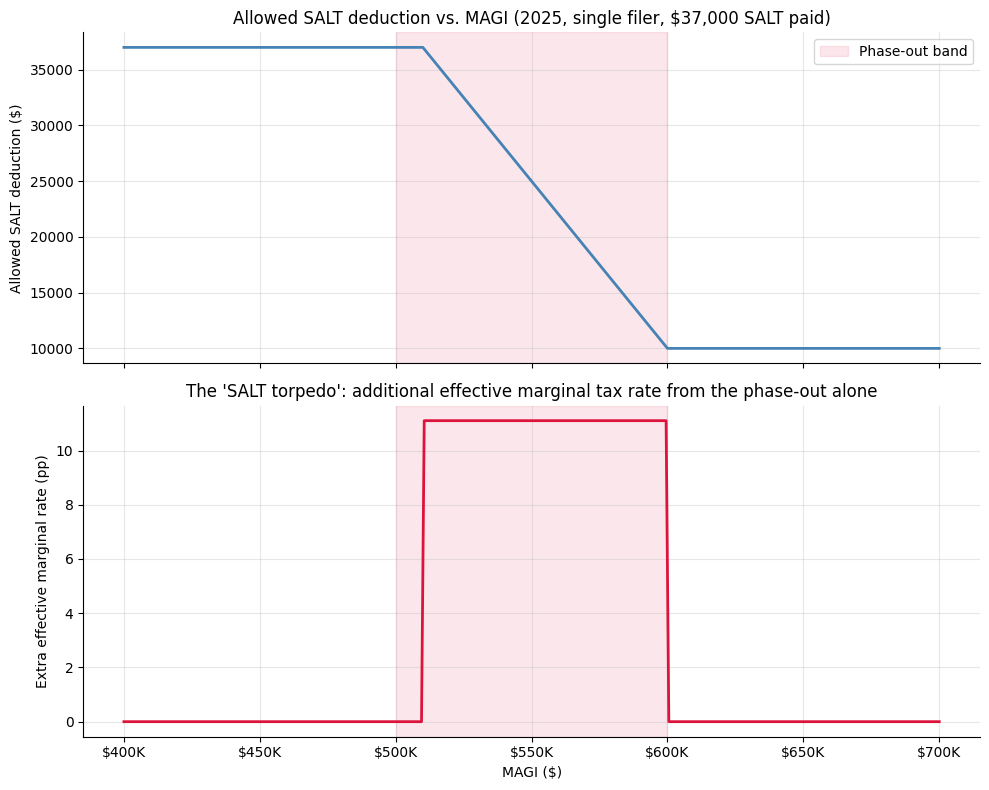

In [11]:
# Build a smooth MAGI grid around the phase-out band and compute the
# ALLOWED SALT deduction at EVERY point -- then take a numerical derivative
# to see the effective "extra tax" from losing deduction as income rises
magi_grid = np.linspace(400_000, 700_000, 601)
salt_paid_fixed = 37_000   # hold SALT paid fixed, isolate the phase-out's effect on deduction alone
allowed_grid = allowed_salt_deduction(magi_grid, salt_paid_fixed, year=2025)

# The MARGINAL loss of deduction per additional dollar of MAGI (a discrete
# derivative) -- this IS the extra effective tax rate the torpedo describes
d_allowed = np.gradient(allowed_grid, magi_grid)
statutory_rate = 0.37                      # top bracket, illustrative
effective_extra_rate = -d_allowed * statutory_rate   # losing deduction -> MORE taxable income -> more tax

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(magi_grid, allowed_grid, color="steelblue", lw=2)
axes[0].axvspan(500_000, 600_000, color="crimson", alpha=0.1, label="Phase-out band")
axes[0].set_ylabel("Allowed SALT deduction ($)")
axes[0].set_title("Allowed SALT deduction vs. MAGI (2025, single filer, $37,000 SALT paid)")
axes[0].legend()

axes[1].plot(magi_grid, effective_extra_rate * 100, color="crimson", lw=2)
axes[1].axvspan(500_000, 600_000, color="crimson", alpha=0.1)
axes[1].set_xlabel("MAGI ($)"); axes[1].set_ylabel("Extra effective marginal rate (pp)")
axes[1].set_title("The 'SALT torpedo': additional effective marginal tax rate from the phase-out alone")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"${x/1000:.0f}K"))

plt.tight_layout()
plt.show()


Outside the \$500K-\$600K band the line is flat — the deduction is either fully available or already at its floor, so income changes there don't touch the SALT deduction. **Inside** the band, every dollar of additional MAGI mechanically shrinks the allowed deduction by 30 cents, which (at a 37% marginal rate) adds roughly **11 extra percentage points** of effective tax on top of the statutory rate — precisely the "torpedo" the cited sources describe.

## 6. Who Benefits: by Income Bracket and by State (`groupby`)


In [12]:
income_bins = [0, 100_000, 250_000, 500_000, 600_000, np.inf]
income_labels = ["<$100K", "$100K-$250K", "$250K-$500K", "$500K-$600K (torpedo band)", "$600K+"]
taxpayers["income_bracket"] = pd.cut(taxpayers["magi"], bins=income_bins, labels=income_labels)

bracket_summary = taxpayers.groupby("income_bracket", observed=True).agg(
    n_taxpayers=("taxpayer_id", "count"),
    avg_salt_benefit=("salt_benefit_2025", "mean"),
    pct_itemizing=("itemizes_2025", "mean"),
).round(1)
bracket_summary


,n_taxpayers,avg_salt_benefit,pct_itemizing
income_bracket,,,
<$100K,9906,8.1,0.0
$100K-$250K,4350,1908.4,0.6
$250K-$500K,570,9867.4,1.0
$500K-$600K (torpedo band),59,9142.7,1.0
$600K+,115,0.0,1.0


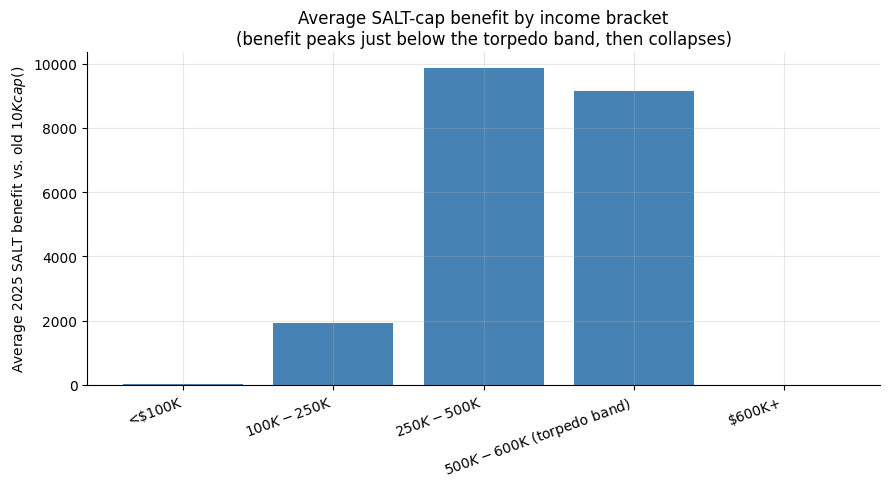

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(bracket_summary.index.astype(str), bracket_summary["avg_salt_benefit"], color="steelblue")
ax.set_ylabel("Average 2025 SALT benefit vs. old $10K cap ($)")
ax.set_title("Average SALT-cap benefit by income bracket\n(benefit peaks just below the torpedo band, then collapses)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


In [14]:
state_summary = taxpayers.groupby("state").agg(
    avg_magi=("magi", "mean"), avg_salt_paid=("salt_paid", "mean"),
    avg_salt_benefit=("salt_benefit_2025", "mean"), pct_itemizing=("itemizes_2025", "mean"),
).round(0).sort_values("avg_salt_benefit", ascending=False)
state_summary


,avg_magi,avg_salt_paid,avg_salt_benefit,pct_itemizing
state,,,,
New York,99565.0,10868.0,2773.0,0.0
New Jersey,101362.0,10593.0,2625.0,0.0
California,100117.0,9492.0,2123.0,0.0
Oregon,117334.0,9957.0,1783.0,0.0
Maryland,101744.0,8638.0,1741.0,0.0
Connecticut,97913.0,8708.0,1736.0,0.0
Illinois,100626.0,8014.0,1306.0,0.0
Massachusetts,100434.0,7489.0,1091.0,0.0
Georgia,104048.0,5135.0,302.0,0.0


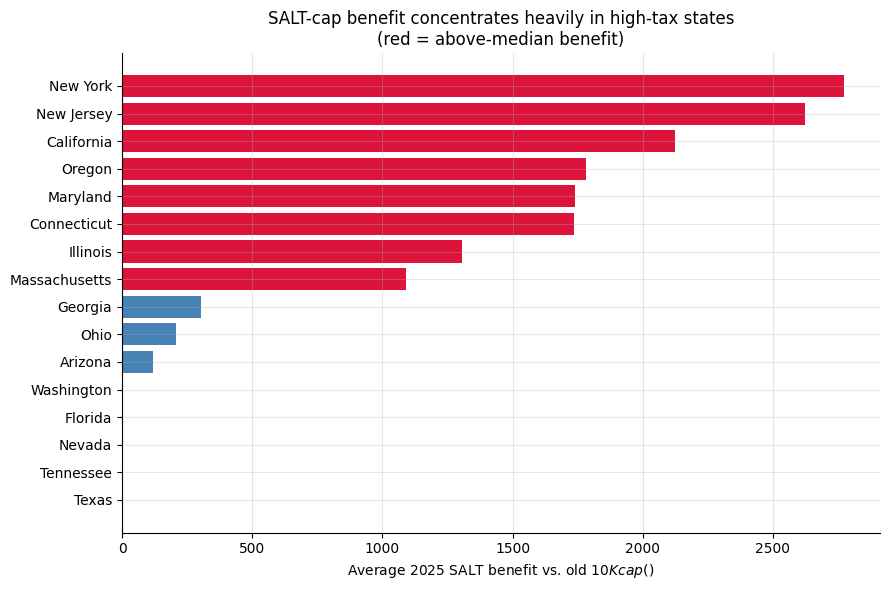

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = ["crimson" if v > state_summary["avg_salt_benefit"].median() else "steelblue"
          for v in state_summary["avg_salt_benefit"]]
ax.barh(state_summary.index[::-1], state_summary["avg_salt_benefit"][::-1], color=colors[::-1])
ax.set_xlabel("Average 2025 SALT benefit vs. old $10K cap ($)")
ax.set_title("SALT-cap benefit concentrates heavily in high-tax states\n(red = above-median benefit)")
plt.tight_layout()
plt.show()


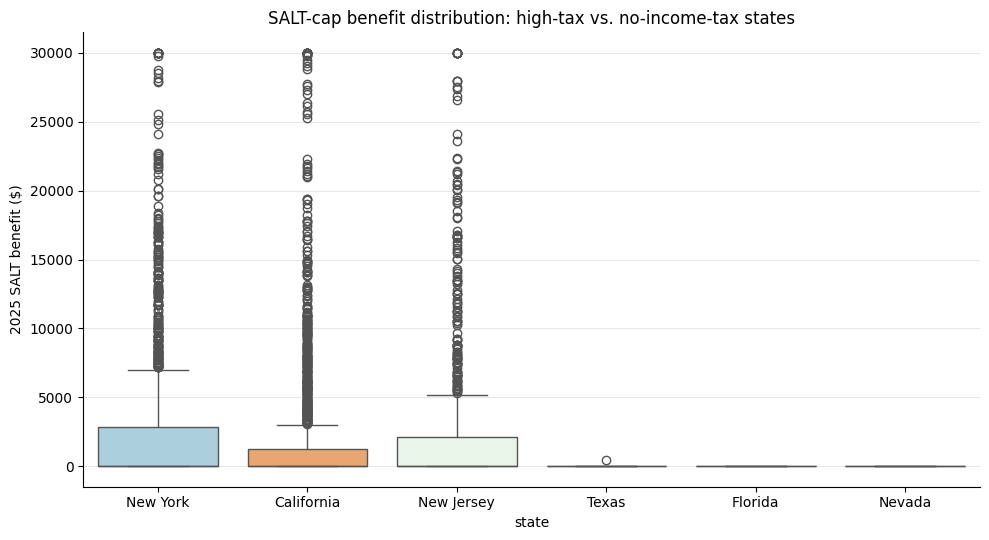

In [16]:
# Seaborn: distribution of benefit by state, for the handful of highest- and
# lowest-tax states -- shows the SPREAD, not just the average
comparison_states = ["New York", "California", "New Jersey", "Texas", "Florida", "Nevada"]
subset = taxpayers[taxpayers["state"].isin(comparison_states)]

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.boxplot(data=subset, x="state", y="salt_benefit_2025", order=comparison_states,
            hue="state", palette="RdYlBu", legend=False, ax=ax)
ax.set_ylabel("2025 SALT benefit ($)")
ax.set_title("SALT-cap benefit distribution: high-tax vs. no-income-tax states")
plt.tight_layout()
plt.show()


## 7. The 2030 Cliff

The full 2018-2031 picture, using the real statutory schedule computed in
Section 1 — the cap doesn't taper down, it **drops immediately** in 2030.


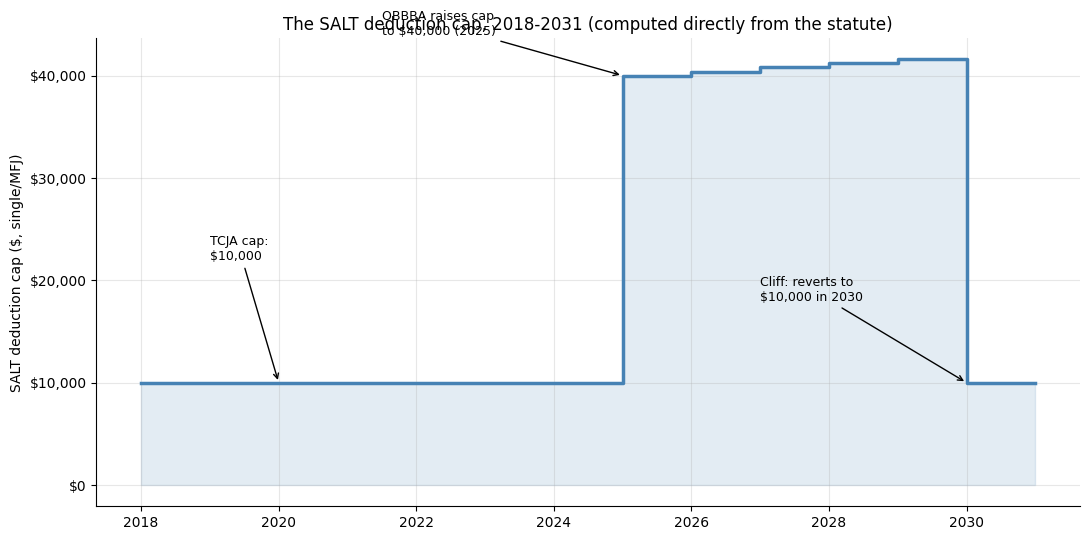

In [17]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.step(salt_schedule["year"], salt_schedule["base_cap"], where="post", color="steelblue", lw=2.5)
ax.fill_between(salt_schedule["year"], salt_schedule["base_cap"], step="post", alpha=0.15, color="steelblue")

ax.annotate("TCJA cap:\n$10,000", xy=(2020, 10_000), xytext=(2019, 22_000),
            arrowprops=dict(arrowstyle="->"), fontsize=9)
ax.annotate("OBBBA raises cap\nto $40,000 (2025)", xy=(2025, 40_000), xytext=(2021.5, 44_000),
            arrowprops=dict(arrowstyle="->"), fontsize=9)
ax.annotate("Cliff: reverts to\n$10,000 in 2030", xy=(2030, 10_000), xytext=(2027, 18_000),
            arrowprops=dict(arrowstyle="->"), fontsize=9)

ax.set_ylabel("SALT deduction cap ($, single/MFJ)")
ax.set_title("The SALT deduction cap, 2018-2031 (computed directly from the statute)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"${x:,.0f}"))
plt.tight_layout()
plt.show()


## 8. One-Page Dashboard


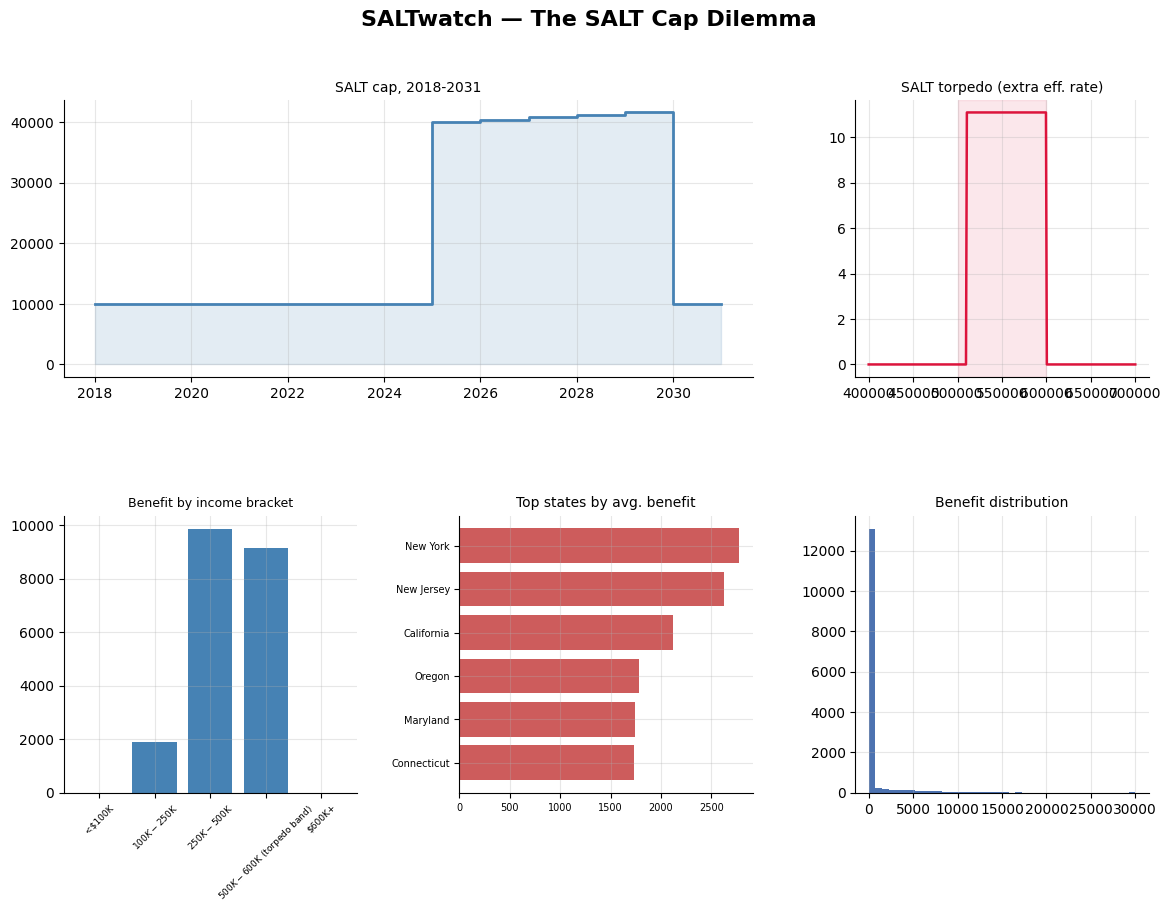

In [18]:
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])
ax1.step(salt_schedule["year"], salt_schedule["base_cap"], where="post", color="steelblue", lw=2)
ax1.fill_between(salt_schedule["year"], salt_schedule["base_cap"], step="post", alpha=0.15, color="steelblue")
ax1.set_title("SALT cap, 2018-2031", fontsize=10)

ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(magi_grid, effective_extra_rate * 100, color="crimson", lw=1.8)
ax2.axvspan(500_000, 600_000, color="crimson", alpha=0.1)
ax2.set_title("SALT torpedo (extra eff. rate)", fontsize=10)

ax3 = fig.add_subplot(gs[1, 0])
ax3.bar(bracket_summary.index.astype(str), bracket_summary["avg_salt_benefit"], color="steelblue")
ax3.set_title("Benefit by income bracket", fontsize=9)
ax3.tick_params(axis="x", labelrotation=45, labelsize=6.5)

ax4 = fig.add_subplot(gs[1, 1])
top6 = state_summary.head(6)
ax4.barh(top6.index[::-1], top6["avg_salt_benefit"][::-1], color="indianred")
ax4.set_title("Top states by avg. benefit", fontsize=10)
ax4.tick_params(labelsize=7)

ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(taxpayers["salt_benefit_2025"], bins=40, color="#4C72B0")
ax5.set_title("Benefit distribution", fontsize=10)

fig.suptitle("SALTwatch — The SALT Cap Dilemma", fontsize=16, fontweight="bold")
plt.show()


## 9. Wrap-up: What This Data Does and Doesn't Settle

### What we built
Starting from the **actual statutory text** of the OBBBA's SALT cap
provision — validated against a real published worked example — we built:

- **NumPy**: a vectorized, exact implementation of the SALT cap formula;
  a full (years × taxpayers) broadcast computing every taxpayer's allowed
  deduction across 14 years at once; boolean masks isolating who newly
  itemizes because of the cap change; fancy indexing to find top beneficiaries;
  and a numerical-derivative computation that turns the phase-out into the
  "SALT torpedo" effective-marginal-rate chart
- **pandas**: `groupby` decomposition by income bracket and by state,
  `pd.cut` bucketing, and comparative distribution analysis
- **Visualization**: the two-panel torpedo chart (the core "dilemma"
  visualization), a step-function cap-schedule chart with the 2030 cliff
  annotated, state and income-bracket comparison bars, Seaborn box plots,
  and a one-page dashboard

### The dilemma, made concrete by the data
The income-bracket chart in Section 6 tells the real story: benefit rises
with income, **peaks for households just below the $500K-$600K torpedo
band**, then **collapses** for the very highest earners who are phased
all the way back down to the original $10,000 cap. Meanwhile the state
chart shows the benefit concentrates overwhelmingly in a handful of
high-tax states — meaning the *same* federal policy change produces
sharply different outcomes depending purely on where a taxpayer lives,
independent of their income.

### Important caveats
- The **taxpayer microdata (income, state assignment, SALT paid, other
  deductions) is entirely synthetic** — calibrated to be realistic, not
  drawn from actual IRS data (which isn't available at the individual
  record level). Don't treat specific dollar figures as citable statistics.
- The **SALT cap formula, standard deduction amounts, and 90%-standard-
  deduction statistic are real**, and the calculator was validated exactly
  against a published worked example.
- This notebook does not take a position on whether the SALT cap increase
  is good policy — reasonable people weigh federal revenue cost,
  state-fairness concerns, and relief for double-taxed high-tax-state
  residents differently. It presents the mechanics; it doesn't adjudicate them.

### Sources cited in this notebook
- Bipartisan Policy Center, *"SALT Deduction Changes in the One Big Beautiful Bill Act"*, Oct 2025
- Holthouse Carlin & Van Trigt LLP, *"OBBBA Expands SALT Deduction Cap Through 2029"*, 2025-2026
- Kahn Litwin, *"SALT Deduction Raised to $40,000 — But a Hidden Phaseout Could Cost You"*, Feb 2026
- STW, *"SALT Deduction Changes: How the $40,000 Cap Impacts High-Income Feds"*, Mar 2026
- CNBC, *"How to maximize the bigger SALT deduction for 2025..."*, Dec 2025
- TurboTax, *"Unlocking the New SALT Cap: How to Save Up to $40,000 This Tax Season"*, Jun 2026
- Katten Muchin Rosenman LLP; PwC Tax Summaries; IRS Revenue Procedure 2025-32

### Where to go next
- Extend the microdata generator with a real income-tax-bracket calculator
  to compute *actual* dollar tax savings (not just deduction size).
- Add the new OBBBA senior deduction (up to $6,000/$12,000, 2025-2028) and
  its own phase-out, which interacts with the same itemize-vs-standard decision.
- Model state-level responses (several states created or expanded
  pass-through entity tax (PTET) elections specifically to route around the
  old SALT cap for business owners — an entirely separate workaround this
  notebook doesn't cover).
- Revisit this analysis close to 2029-2030 as the cliff approaches and
  Congress decides whether to extend, modify, or allow the reversion.
